## Sequence Diagram: Frontend → Backend → MAS System 2/System 1 → ChromaDB

```mermaid
sequenceDiagram
    autonumber
    actor U as User
    participant FE as Frontend (React)
    participant BE as Backend API (Spring Boot)
    participant FL as Flask MAS API
    participant CM as ConversationManager
    participant G as LangGraph System 2
    participant IA as IntentAgent
    participant CA as ClarificationAgent
    participant PA as PlanningAgent
    participant OCR as Image2TextAgent (OCR)
    participant OR as Orchestrator (System 1)
    participant EX as ExtractorAgent
    participant AB as AbstracterAgent
    participant EV as EvaluationAgent
    participant CH as ChromaDB (Memory/Vector DB)

    U->>FE: Nhập yêu cầu tóm tắt
    FE->>BE: POST /api/mas/chat
    BE->>FL: Forward request /api/mas/chat
    FL->>CM: cm.chat(sessionId, userInput)

    CM->>CH: Semantic recall (lấy ngữ cảnh liên quan)
    CH-->>CM: Similar memories

    CM->>G: graph.invoke(state)

    G->>IA: intent_node (phân loại intent/strategy/grade/image)
    IA-->>G: intent

    G->>CA: clarification_node
    alt Thiếu thông tin
        CA-->>G: clarification_needed=true + question
        G-->>CM: final_output = câu hỏi làm rõ
        CM->>CH: Lưu user/assistant messages
        CM-->>FL: Kết quả cần làm rõ
        FL-->>BE: JSON response
        BE-->>FE: Trả clarification_question
        FE-->>U: Hiển thị câu hỏi làm rõ
    else Đủ thông tin
        CA-->>G: clarification_needed=false
        G->>PA: planning_node (tạo pipeline)
        PA-->>G: plan

        opt Plan có bước OCR
            G->>OCR: ocr_node (đọc ảnh -> text)
            OCR-->>G: extracted_text/original_text
        end

        G->>OR: summarize_node gọi system1_engine.run()
        alt strategy = extractive
            OR->>EX: Tóm tắt trích xuất
            EX-->>OR: summary
        else strategy = abstractive
            OR->>AB: Tóm tắt diễn giải
            AB-->>OR: summary
        end
        OR-->>G: summary

        G->>EV: evaluation_node (ROUGE/BERTScore/quality)
        EV-->>G: evaluation + needs_improvement

        alt needs_improvement = true
            G->>PA: Quay lại planning (self-improvement loop)
            PA-->>G: plan mới
            G->>OR: summarize lại
            OR-->>G: summary mới
            G->>EV: evaluate lại
            EV-->>G: evaluation mới
        end

        G-->>CM: final_output + full mas_state
        CM->>CH: Lưu hội thoại + tool usage + knowledge patterns
        CM-->>FL: output + state + memory_data
        FL-->>BE: JSON response

        BE-->>FE: final_output + intent/plan/summary/evaluation
        FE-->>U: Hiển thị kết quả cuối
    end

    Note over U,CH: KẾT THÚC PHIÊN XỬ LÝ
```

## Các bước ngắn gọn để viết báo cáo

1. User nhập yêu cầu tại Frontend.
2. Frontend gọi Backend qua `POST /api/mas/chat`.
3. Backend chuyển request sang Flask MAS API.
4. ConversationManager lấy ngữ cảnh liên quan từ ChromaDB.
5. System 2 chạy `IntentAgent` để nhận diện yêu cầu.
6. `ClarificationAgent` kiểm tra thiếu dữ liệu; nếu thiếu thì hỏi lại user.
7. Nếu đủ dữ liệu, `PlanningAgent` tạo pipeline xử lý.
8. Nếu input là ảnh, `Image2TextAgent` OCR để lấy văn bản.
9. Node tóm tắt gọi System 1 (`Orchestrator`).
10. System 1 dùng `ExtractorAgent` hoặc `AbstracterAgent` theo strategy.
11. `EvaluationAgent` chấm chất lượng; nếu thấp thì lặp cải thiện.
12. Trả kết quả về Backend rồi Frontend hiển thị cho user.
13. Lưu memory/tri thức vào ChromaDB và kết thúc lượt xử lý.

In [3]:
import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import numpy as np
import os

try:
    from py_vncorenlp import VnCoreNLP
    rdrsegmenter = VnCoreNLP("https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar", annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')
    USE_VNCORENLP = True
except:
    USE_VNCORENLP = False
    import re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(
            encoder.config.hidden_size, 1
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        scores = self.classifier(cls_embeddings)
        return scores
model = PhoBERTSUM(phobert).to(DEVICE)
model.eval()   # inference mode
def sent_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.strip()
    if not text:
        return []
    
    if USE_VNCORENLP:
        try:
            sentences = rdrsegmenter.sent_tokenize(text)
            sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
            return sentences
        except:
            pass
    
    sentences = re.split(r'[.!?]+\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]
def get_top_k_by_ratio(num_sentences, ratio=0.6):
    return max(1, int(num_sentences * ratio))
def encode_sentences(sentences, max_len=256):
    encoded = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return encoded["input_ids"].to(DEVICE), encoded["attention_mask"].to(DEVICE)
@torch.no_grad()
def extractive_summary(text, ratio=0.6):
    sentences = split_sentences(text)
    n = len(sentences)

    if n == 0:
        return ""

    # Nếu chỉ có 1 câu → lấy luôn
    if n == 1:
        return sentences[0]

    top_k = get_top_k_by_ratio(n, ratio)

    input_ids, attention_mask = encode_sentences(sentences)
    scores = model(input_ids, attention_mask)

    scores = scores.squeeze().cpu()

    # ĐẢM BẢO top_idx LUÔN là list
    top_idx = torch.topk(
        scores, min(top_k, n)
    ).indices.tolist()

    if not isinstance(top_idx, list):
        top_idx = [top_idx]

    top_idx.sort()

    summary = " ".join(sentences[i] for i in top_idx)
    return summary

rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_summary(candidate, reference):
    if not candidate or not reference:
        return {
            'f1': 0.0,
            'rouge1': 0.0,
            'rougel': 0.0,
            'bertscore': 0.0
        }
    
    rouge_scores = rouge_scorer_obj.score(reference, candidate)
    rouge1 = rouge_scores['rouge1'].fmeasure
    rougel = rouge_scores['rougeL'].fmeasure
    
    try:
        P, R, F1_bert = bert_score([candidate], [reference], lang='vi', verbose=False)
        bertscore = F1_bert.item()
    except:
        bertscore = 0.0
    
    candidate_tokens = set(candidate.lower().split())
    reference_tokens = set(reference.lower().split())
    if len(reference_tokens) == 0:
        f1 = 0.0
    else:
        intersection = candidate_tokens & reference_tokens
        precision = len(intersection) / len(candidate_tokens) if len(candidate_tokens) > 0 else 0
        recall = len(intersection) / len(reference_tokens) if len(reference_tokens) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'f1': f1,
        'rouge1': rouge1,
        'rougel': rougel,
        'bertscore': bertscore
    }

def select_best_summary(summaries_dict):
    if not summaries_dict:
        return None, {}
    
    best_key = None
    best_scores = None
    
    for key, scores in summaries_dict.items():
        if best_key is None:
            best_key = key
            best_scores = scores
            continue
        
        if scores['f1'] > best_scores['f1']:
            best_key = key
            best_scores = scores
        elif scores['f1'] == best_scores['f1']:
            if scores['rougel'] > best_scores['rougel']:
                best_key = key
                best_scores = scores
            elif scores['rougel'] == best_scores['rougel']:
                if scores['rouge1'] > best_scores['rouge1']:
                    best_key = key
                    best_scores = scores
                elif scores['rouge1'] == best_scores['rouge1']:
                    if scores['bertscore'] > best_scores['bertscore']:
                        best_key = key
                        best_scores = scores
    
    return best_key, best_scores

c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [4]:
INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_summary.xlsx"

df = pd.read_excel(INPUT_XLSX)

if 'f1' not in df.columns:
    df['f1'] = np.nan
if 'rougel' not in df.columns:
    df['rougel'] = np.nan
if 'rouge1' not in df.columns:
    df['rouge1'] = np.nan
if 'bertscore' not in df.columns:
    df['bertscore'] = np.nan

reference_col = None
for col in ['reference_summary', 'gold_summary', 'reference', 'gold']:
    if col in df.columns:
        reference_col = col
        break

for idx, row in df.iterrows():
    content = row["content"]
    if pd.isna(content) or content == "":
        continue
    
    reference = ""
    if reference_col and reference_col in row:
        ref_val = row[reference_col]
        if not pd.isna(ref_val) and ref_val != "":
            reference = str(ref_val)
    elif not pd.isna(row.get("summary", "")) and row.get("summary", "") != "":
        reference = str(row["summary"])
    
    best_summary = None
    best_scores = None
    
    for retry in range(5):
        summary = extractive_summary(content, ratio=0.6)
        
        if reference and reference.strip():
            scores = evaluate_summary(summary, reference)
        else:
            scores = {'f1': 0.0, 'rouge1': 0.0, 'rougel': 0.0, 'bertscore': 0.0}
        
        if (scores['f1'] >= 0.5 and 
            scores['rouge1'] >= 0.45 and 
            scores['rougel'] >= 0.4 and 
            scores['bertscore'] >= 0.8):
            best_summary = summary
            best_scores = scores
            break
    
    if best_summary is not None:
        df.at[idx, "summary"] = best_summary
        df.at[idx, "f1"] = best_scores['f1']
        df.at[idx, "rougel"] = best_scores['rougel']
        df.at[idx, "rouge1"] = best_scores['rouge1']
        df.at[idx, "bertscore"] = best_scores['bertscore']

df.to_excel(OUTPUT_XLSX, index=False)

print("✅ Đã tạo xong bản tóm tắt trích xuất")


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Project_NguyenMinhVu_2211110063\\Source\\datasets\\dataset extractive\\DATA_TX.xlsx'

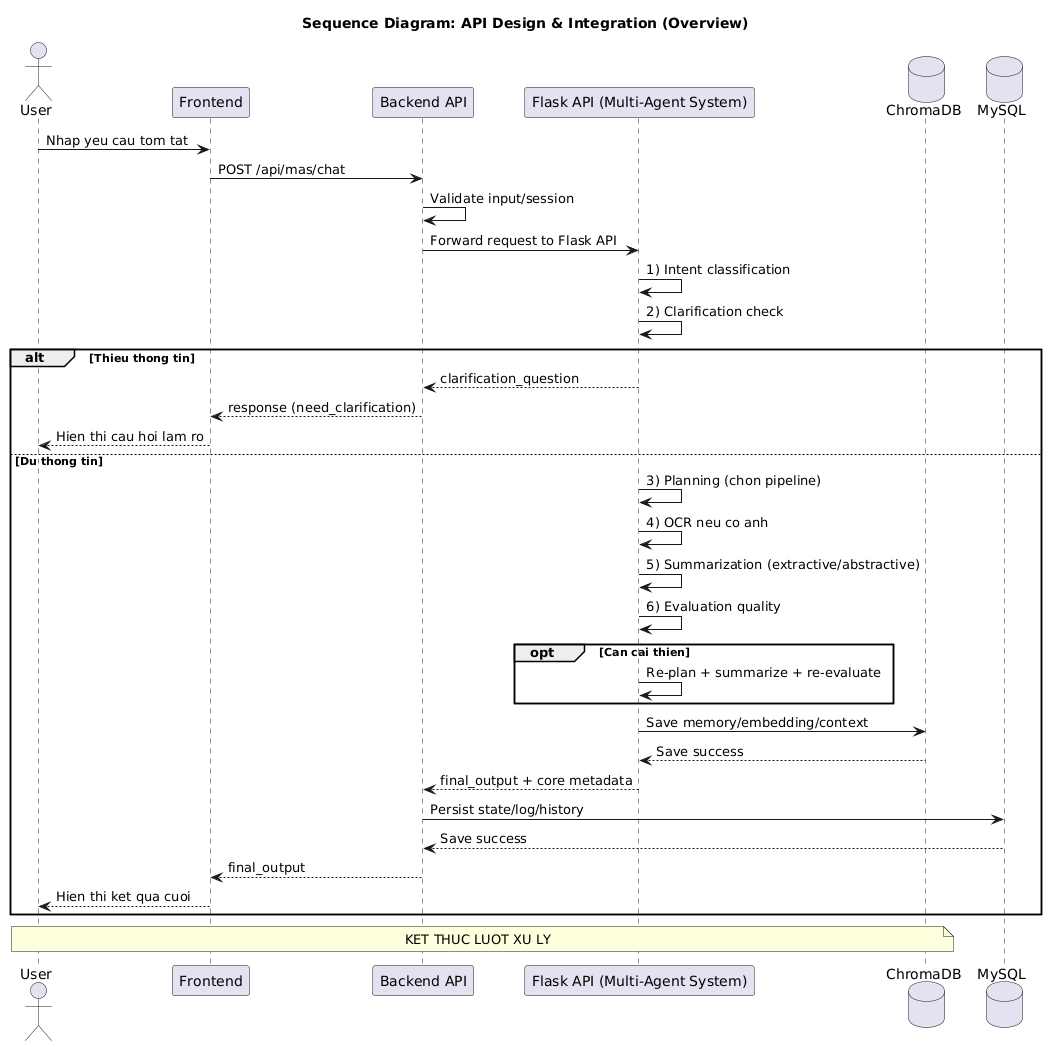

In [3]:
from plantuml import PlantUML
from IPython.display import Image, display

uml_code = """
@startuml
title Sequence Diagram: API Design & Integration (Overview)

actor User as U
participant "Frontend" as FE
participant "Backend API" as BE
participant "Flask API (Multi-Agent System)" as FL
database "ChromaDB" as DB
database "MySQL" as SQL

U -> FE : Nhap yeu cau tom tat
FE -> BE : POST /api/mas/chat

BE -> BE : Validate input/session
BE -> FL : Forward request to Flask API

FL -> FL : 1) Intent classification
FL -> FL : 2) Clarification check

alt Thieu thong tin
  FL --> BE : clarification_question
  BE --> FE : response (need_clarification)
  FE --> U : Hien thi cau hoi lam ro
else Du thong tin
  FL -> FL : 3) Planning (chon pipeline)
  FL -> FL : 4) OCR neu co anh
  FL -> FL : 5) Summarization (extractive/abstractive)
  FL -> FL : 6) Evaluation quality
  opt Can cai thien
    FL -> FL : Re-plan + summarize + re-evaluate
  end

  FL -> DB : Save memory/embedding/context
  DB --> FL : Save success

  FL --> BE : final_output + core metadata
  BE -> SQL : Persist state/log/history
  SQL --> BE : Save success
  BE --> FE : final_output
  FE --> U : Hien thi ket qua cuoi
end

note over U,DB
KET THUC LUOT XU LY
end note

@enduml
"""

# Kết nối đến PlantUML server
server = PlantUML(url="http://www.plantuml.com/plantuml/png/")

# Gửi UML code đến server và nhận về dữ liệu ảnh
image_data = server.processes(uml_code)

# Hiển thị ảnh trực tiếp trong notebook
display(Image(image_data))

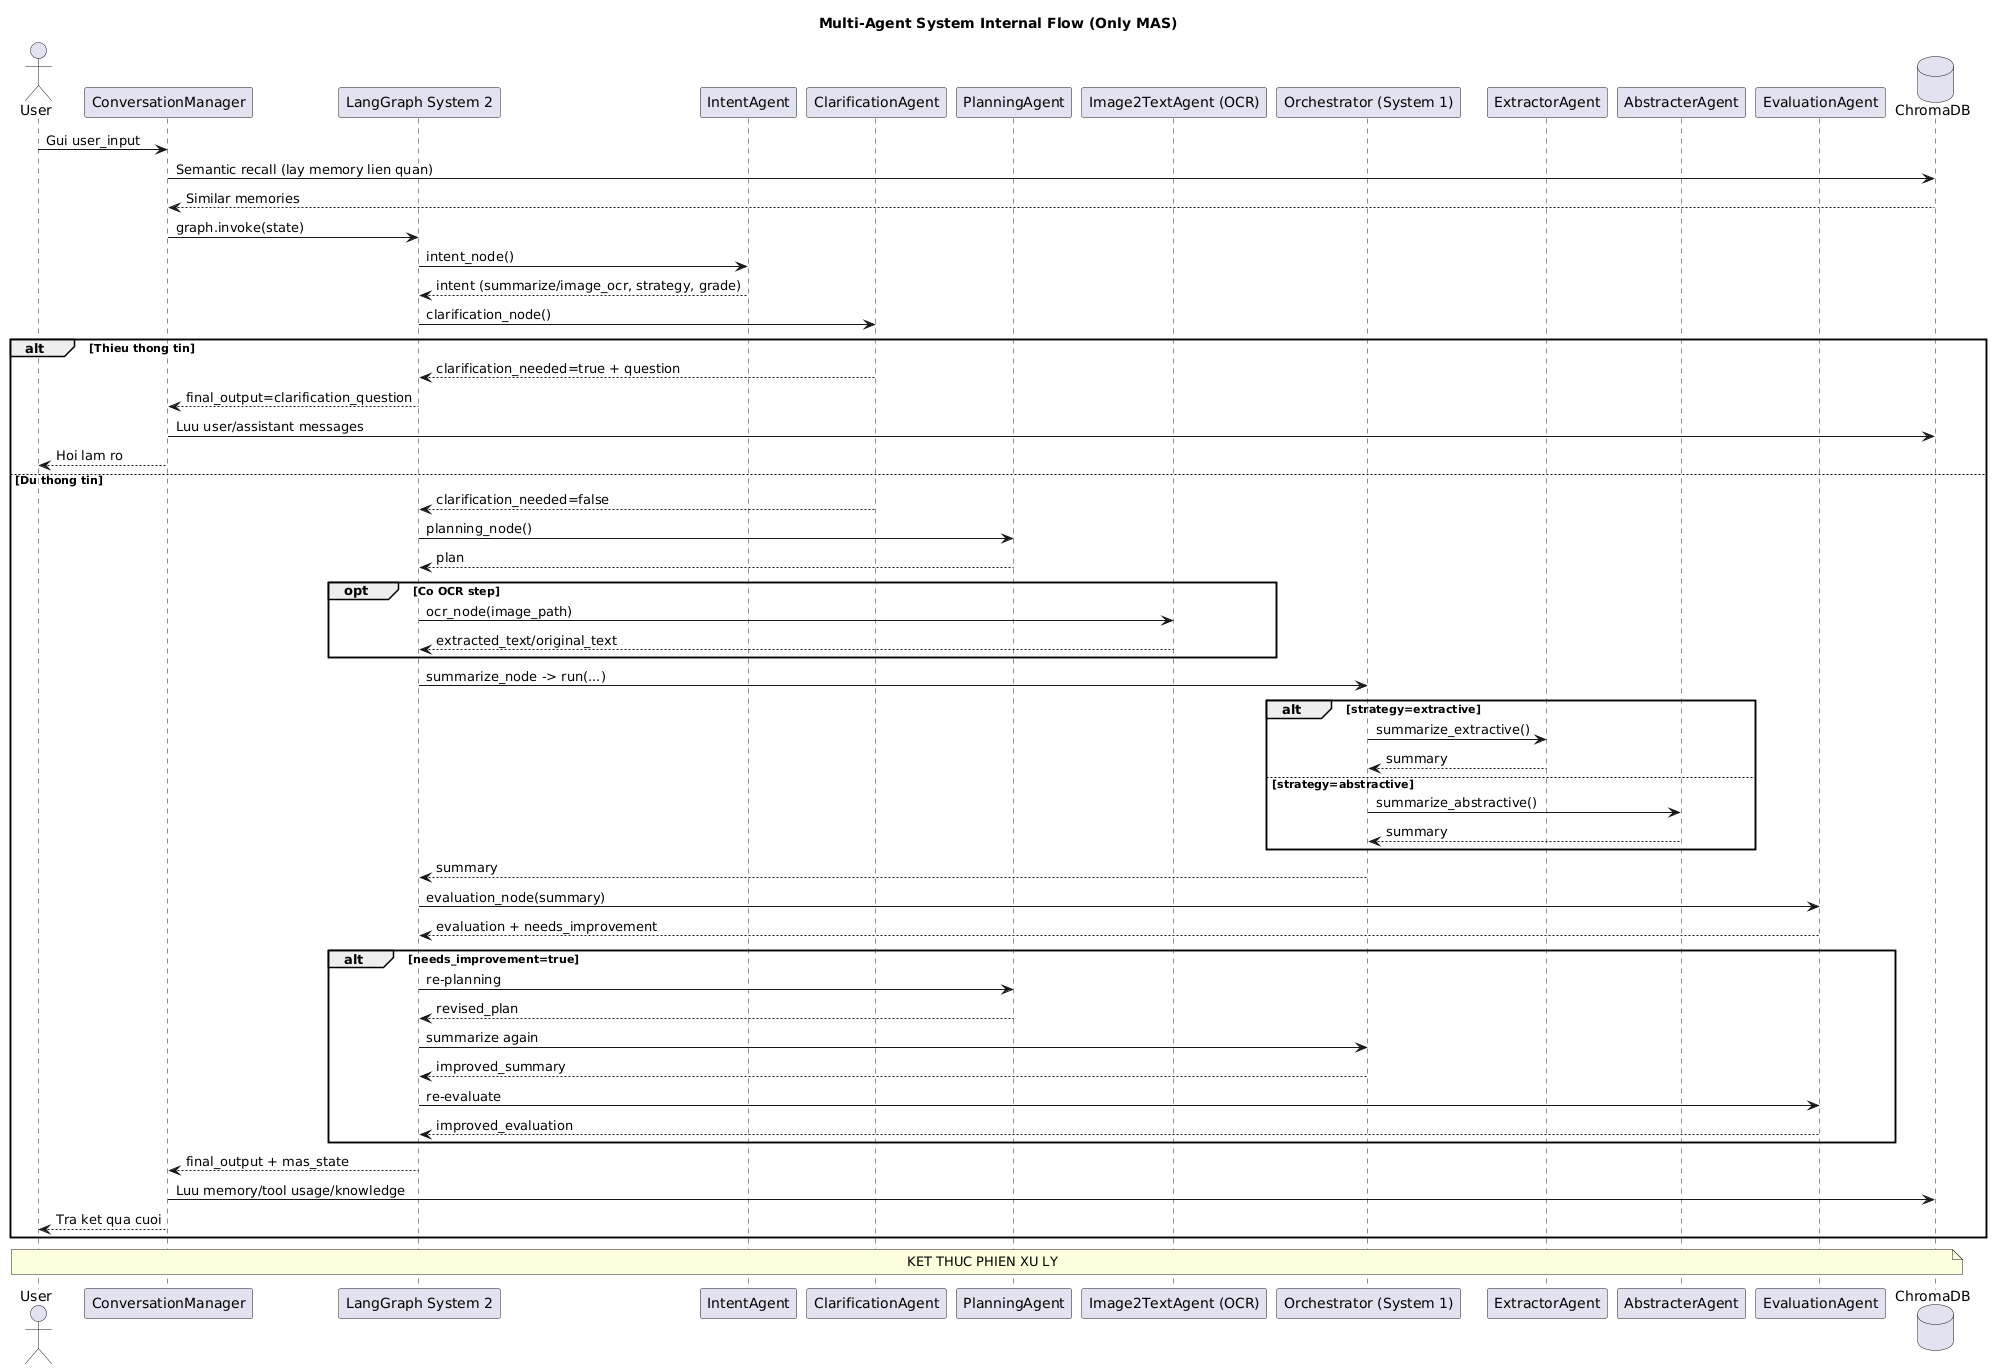

In [2]:
from plantuml import PlantUML
from IPython.display import Image, display

uml_code = """
@startuml
title Multi-Agent System Internal Flow (Only MAS)
actor User as U
participant "ConversationManager" as CM
participant "LangGraph System 2" as SYS2
participant "IntentAgent" as IA
participant "ClarificationAgent" as CA
participant "PlanningAgent" as PA
participant "Image2TextAgent (OCR)" as OCR
participant "Orchestrator (System 1)" as SYS1
participant "ExtractorAgent" as EX
participant "AbstracterAgent" as AB
participant "EvaluationAgent" as EV
database "ChromaDB" as CH
U -> CM : Gui user_input
CM -> CH : Semantic recall (lay memory lien quan)
CH --> CM : Similar memories
CM -> SYS2 : graph.invoke(state)
SYS2 -> IA : intent_node()
IA --> SYS2 : intent (summarize/image_ocr, strategy, grade)
SYS2 -> CA : clarification_node()
alt Thieu thong tin
  CA --> SYS2 : clarification_needed=true + question
  SYS2 --> CM : final_output=clarification_question
  CM -> CH : Luu user/assistant messages
  CM --> U : Hoi lam ro
else Du thong tin
  CA --> SYS2 : clarification_needed=false
  SYS2 -> PA : planning_node()
  PA --> SYS2 : plan
  opt Co OCR step
    SYS2 -> OCR : ocr_node(image_path)
    OCR --> SYS2 : extracted_text/original_text
  end
  SYS2 -> SYS1 : summarize_node -> run(...)
  alt strategy=extractive
    SYS1 -> EX : summarize_extractive()
    EX --> SYS1 : summary
  else strategy=abstractive
    SYS1 -> AB : summarize_abstractive()
    AB --> SYS1 : summary
  end
  SYS1 --> SYS2 : summary
  SYS2 -> EV : evaluation_node(summary)
  EV --> SYS2 : evaluation + needs_improvement
  alt needs_improvement=true
    SYS2 -> PA : re-planning
    PA --> SYS2 : revised_plan
    SYS2 -> SYS1 : summarize again
    SYS1 --> SYS2 : improved_summary
    SYS2 -> EV : re-evaluate
    EV --> SYS2 : improved_evaluation
  end
  SYS2 --> CM : final_output + mas_state
  CM -> CH : Luu memory/tool usage/knowledge
  CM --> U : Tra ket qua cuoi
end
note over U,CH
KET THUC PHIEN XU LY
end note
@enduml
"""

# Kết nối đến PlantUML server
server = PlantUML(url="http://www.plantuml.com/plantuml/png/")

# Gửi UML code đến server và nhận về dữ liệu ảnh
image_data = server.processes(uml_code)

# Hiển thị ảnh trực tiếp trong notebook
display(Image(image_data))

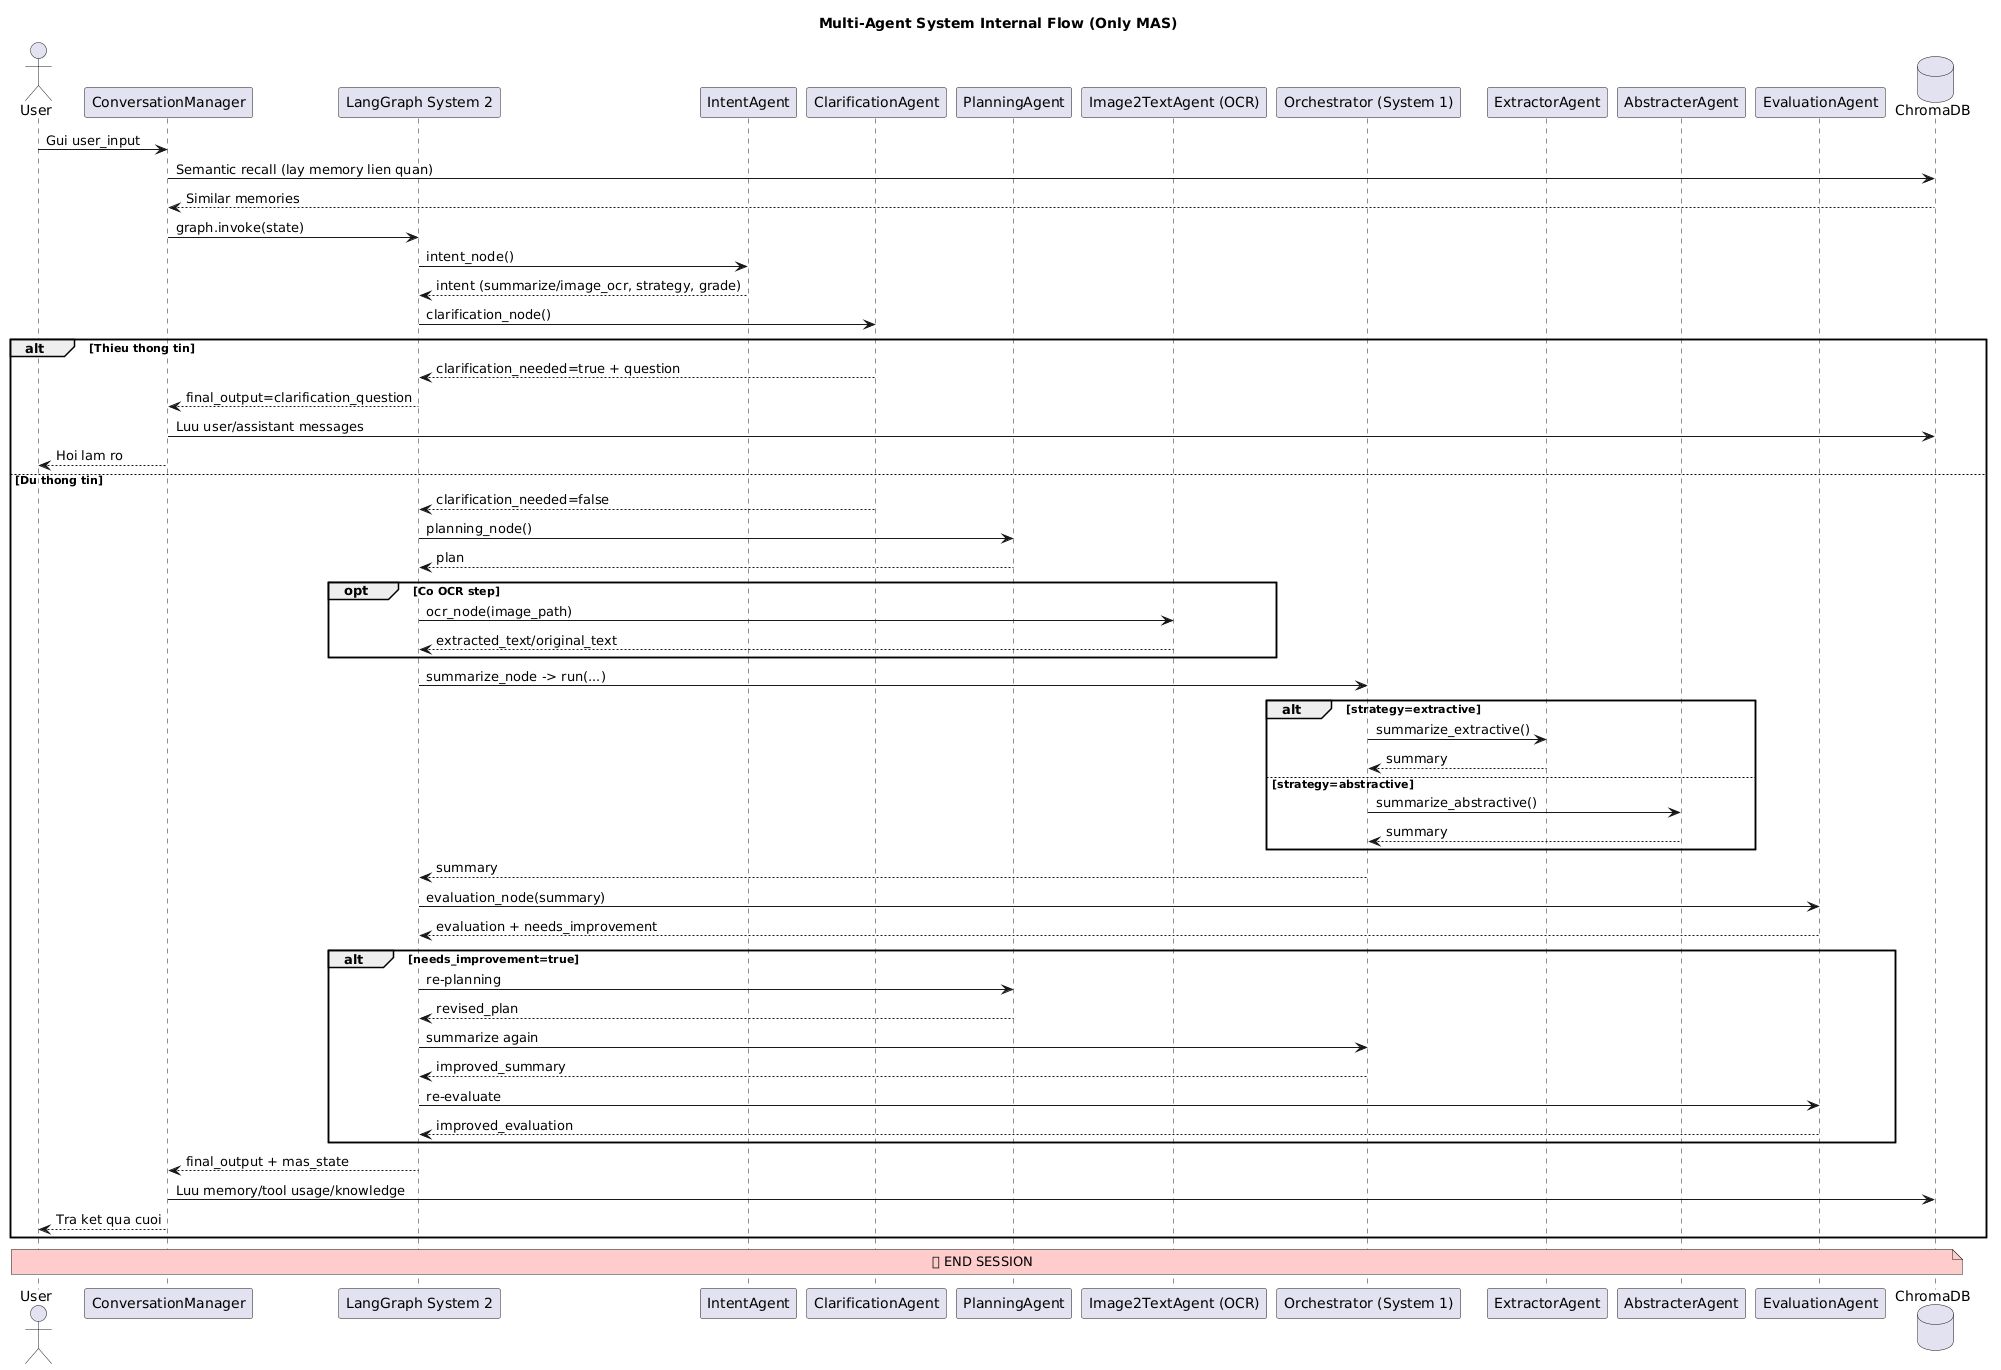

In [19]:
from plantuml import PlantUML
from IPython.display import Image, display

uml_code = """
@startuml
title Multi-Agent System Internal Flow (Only MAS)
actor User as U
participant "ConversationManager" as CM
participant "LangGraph System 2" as SYS2
participant "IntentAgent" as IA
participant "ClarificationAgent" as CA
participant "PlanningAgent" as PA
participant "Image2TextAgent (OCR)" as OCR
participant "Orchestrator (System 1)" as SYS1
participant "ExtractorAgent" as EX
participant "AbstracterAgent" as AB
participant "EvaluationAgent" as EV
database "ChromaDB" as CH
U -> CM : Gui user_input
CM -> CH : Semantic recall (lay memory lien quan)
CH --> CM : Similar memories
CM -> SYS2 : graph.invoke(state)
SYS2 -> IA : intent_node()
IA --> SYS2 : intent (summarize/image_ocr, strategy, grade)
SYS2 -> CA : clarification_node()
alt Thieu thong tin
  CA --> SYS2 : clarification_needed=true + question
  SYS2 --> CM : final_output=clarification_question
  CM -> CH : Luu user/assistant messages
  CM --> U : Hoi lam ro
else Du thong tin
  CA --> SYS2 : clarification_needed=false
  SYS2 -> PA : planning_node()
  PA --> SYS2 : plan
  opt Co OCR step
    SYS2 -> OCR : ocr_node(image_path)
    OCR --> SYS2 : extracted_text/original_text
  end
  SYS2 -> SYS1 : summarize_node -> run(...)
  alt strategy=extractive
    SYS1 -> EX : summarize_extractive()
    EX --> SYS1 : summary
  else strategy=abstractive
    SYS1 -> AB : summarize_abstractive()
    AB --> SYS1 : summary
  end
  SYS1 --> SYS2 : summary
  SYS2 -> EV : evaluation_node(summary)
  EV --> SYS2 : evaluation + needs_improvement
  alt needs_improvement=true
    SYS2 -> PA : re-planning
    PA --> SYS2 : revised_plan
    SYS2 -> SYS1 : summarize again
    SYS1 --> SYS2 : improved_summary
    SYS2 -> EV : re-evaluate
    EV --> SYS2 : improved_evaluation
  end
  SYS2 --> CM : final_output + mas_state
  CM -> CH : Luu memory/tool usage/knowledge
  CM --> U : Tra ket qua cuoi
end
note over U,CH #FFCCCC
❌ END SESSION
end note
@enduml
"""

# Kết nối đến PlantUML server
server = PlantUML(url="http://www.plantuml.com/plantuml/png/")

# Gửi UML code đến server và nhận về dữ liệu ảnh
image_data = server.processes(uml_code)

# Hiển thị ảnh trực tiếp trong notebook
display(Image(image_data))

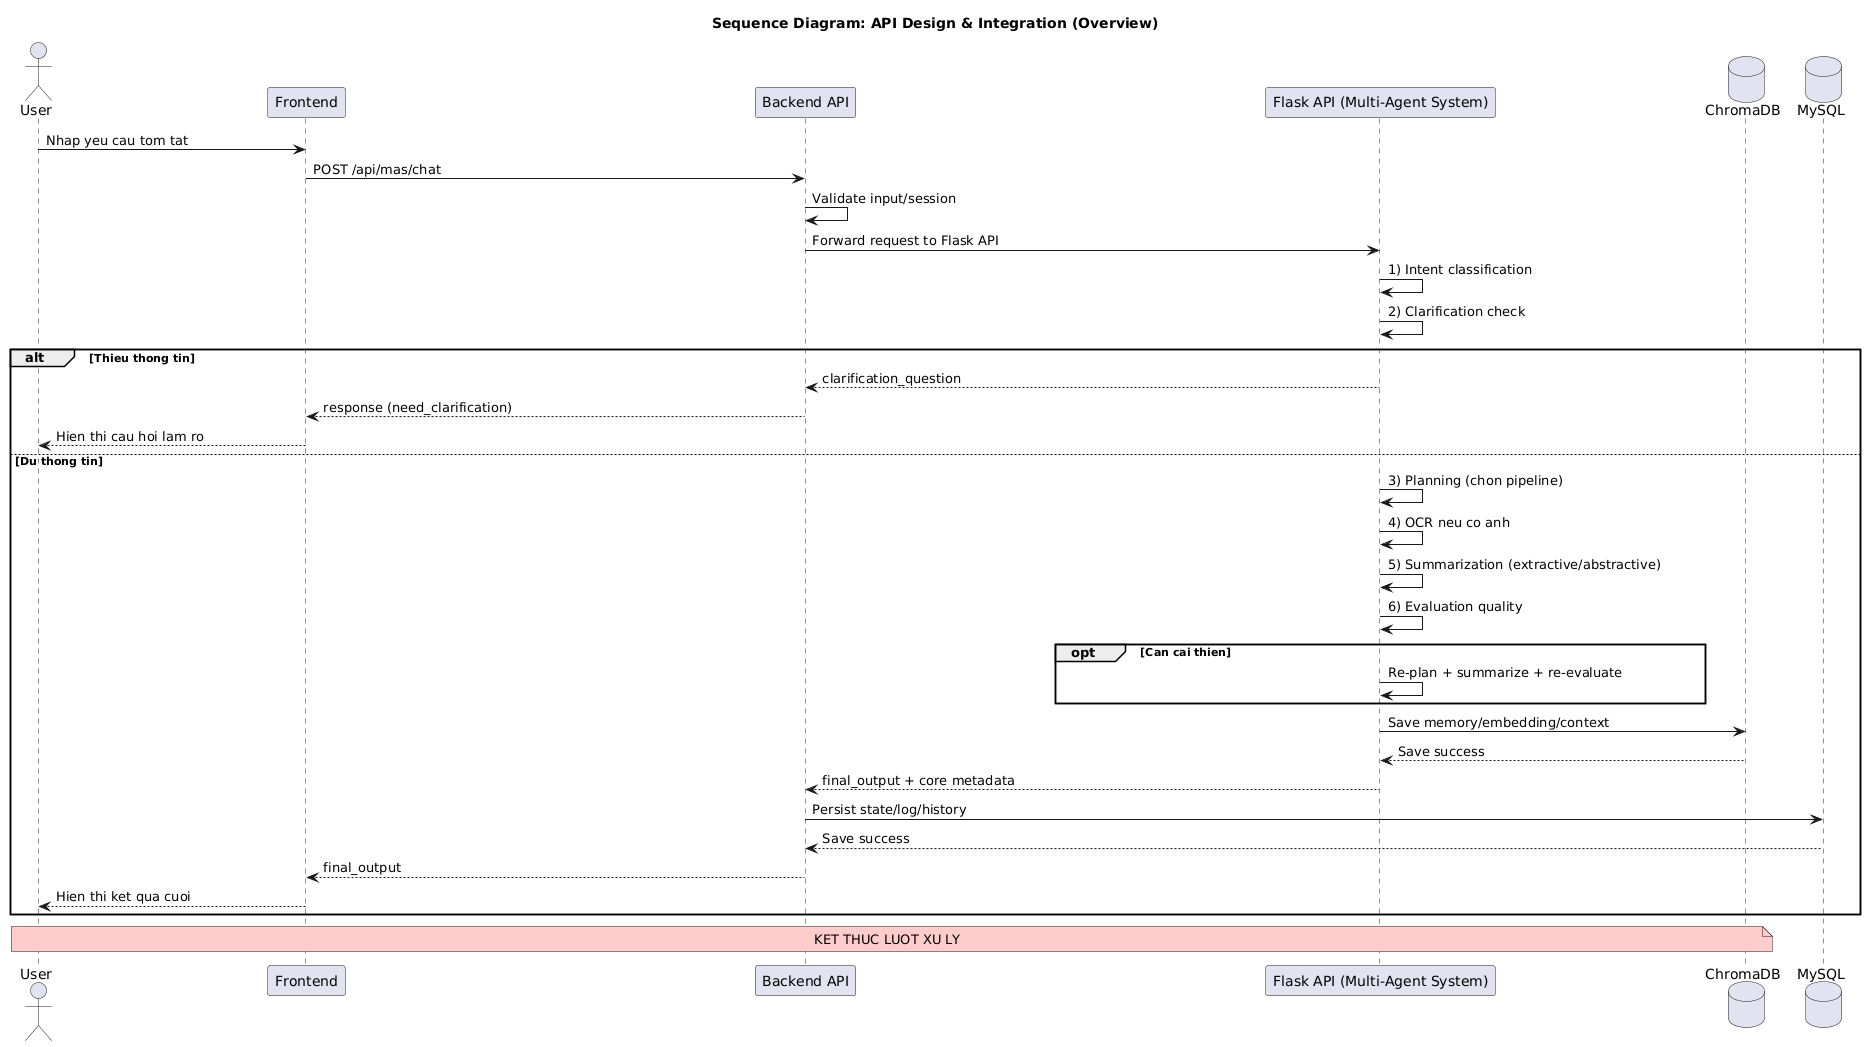

In [29]:
from plantuml import PlantUML
from IPython.display import Image, display

uml_code = """
@startuml
title Sequence Diagram: API Design & Integration (Overview)

skinparam maxMessageSize 1000
skinparam ParticipantPadding 200
skinparam BoxPadding 10

actor User as U
participant "Frontend" as FE
participant "Backend API" as BE
participant "Flask API (Multi-Agent System)" as FL
database "ChromaDB" as DB
database "MySQL" as SQL

U -> FE : Nhap yeu cau tom tat
FE -> BE : POST /api/mas/chat

BE -> BE : Validate input/session
BE -> FL : Forward request to Flask API

FL -> FL : 1) Intent classification
FL -> FL : 2) Clarification check

alt Thieu thong tin
  FL --> BE : clarification_question
  BE --> FE : response (need_clarification)
  FE --> U : Hien thi cau hoi lam ro
else Du thong tin
  FL -> FL : 3) Planning (chon pipeline)
  FL -> FL : 4) OCR neu co anh
  FL -> FL : 5) Summarization (extractive/abstractive)
  FL -> FL : 6) Evaluation quality
  opt Can cai thien
    FL -> FL : Re-plan + summarize + re-evaluate
  end

  FL -> DB : Save memory/embedding/context
  DB --> FL : Save success

  FL --> BE : final_output + core metadata
  BE -> SQL : Persist state/log/history
  SQL --> BE : Save success
  BE --> FE : final_output
  FE --> U : Hien thi ket qua cuoi
end

note over U,DB #FFCCCC
KET THUC LUOT XU LY
end note

@enduml
"""

server = PlantUML(url="http://www.plantuml.com/plantuml/png/")
image_data = server.processes(uml_code)
display(Image(image_data))